In [3]:
library(tidyverse)
library(knitr)
library(scales)
library(patchwork)
library(corrplot)
library(broom)
library(AER)
library(modelr)
library(ISLR)
library(dplyr)
install.packages("arm")
library(arm)

Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'readr' was built under R version 4.5.3"
Warning message:
"package 'forcats' was built under R version 4.5.3"
Warning message:
"package 'lubridate' was built under R version 4.5.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'knitr' was built under R version 4.5.3"
Warning message:
"package 'scales' was built under R version 4.5.3"

Attaching package: 'scales'


The following object is masked f

package 'arm' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\woobi\AppData\Local\Temp\RtmpWyIJKd\downloaded_packages


Warning message:
"package 'arm' was built under R version 4.5.3"
Loading required package: MASS


Attaching package: 'MASS'


The following object is masked from 'package:patchwork':

    area


The following object is masked from 'package:dplyr':

    select


Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loading required package: lme4


arm (Version 1.15-3, built: 2026-4-15)


Working directory is c:/Users/woobi/OneDrive/바탕 화면/UBC/STAT 301/stat301-project



Attaching package: 'arm'


The following object is masked from 'package:car':

    logit


The following object is masked from 'package:corrplot':

    corrplot


The following object is masked from 'package:scales':

    rescale




In [4]:
data <- read_csv("Toronto_apartment_rentals_2018.csv")

Rows: 1124 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): Address, Price
dbl (5): Bedroom, Bathroom, Den, Lat, Long

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [6]:
data <- data %>%
  # Removing duplicate rows
  distinct() %>%
  # Removing unnecessary columns
  dplyr::select(-c(Address, Lat, Long)) %>%
  # Making the column names lowercase
  rename_with(tolower) %>%
  # Converting price to a number
  mutate(price = parse_number(price)) %>%
  # Removing outliers
  filter(!price %in% c(65, 99, 99, 36900, 535000)) %>%
mutate(high_price = if_else(price > mean(price), 1, 0))

In [7]:
data <- data %>%
  mutate(high_price = if_else(price > mean(price), 1, 0))

In [8]:
nrow(data)
head(data)

[1] 811

bedroom,bathroom,den,price,high_price
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,2,0,2450,1
1,1,1,2150,0
1,1,0,1950,0
2,2,0,2900,1
1,1,0,1800,0
1,1,0,1729,0


In [16]:
summary(data)

    bedroom         bathroom          den             price     
 Min.   :1.000   Min.   :1.000   Min.   :0.0000   Min.   : 150  
 1st Qu.:1.000   1st Qu.:1.000   1st Qu.:0.0000   1st Qu.:1750  
 Median :1.000   Median :1.000   Median :0.0000   Median :2100  
 Mean   :1.369   Mean   :1.239   Mean   :0.1541   Mean   :2186  
 3rd Qu.:2.000   3rd Qu.:1.000   3rd Qu.:0.0000   3rd Qu.:2500  
 Max.   :3.000   Max.   :3.000   Max.   :1.0000   Max.   :9750  
   high_price    
 Min.   :0.0000  
 1st Qu.:0.0000  
 Median :0.0000  
 Mean   :0.4698  
 3rd Qu.:1.0000  
 Max.   :1.0000  

In [9]:
linear_add <- lm(price ~ bedroom + bathroom, data = data)

linear_add_results <- 
   tidy(linear_add, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1026.44,74.50,13.78,0,880.20,1172.68
bedroom,206.60,54.54,3.79,0,99.53,313.66
bathroom,707.66,70.73,10.01,0,568.83,846.49


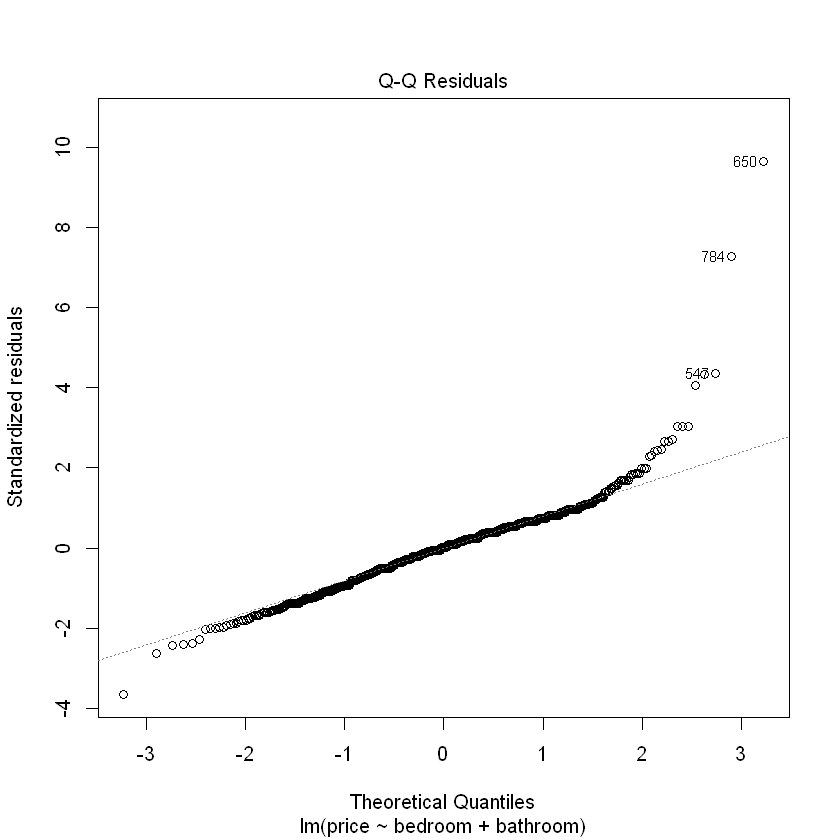

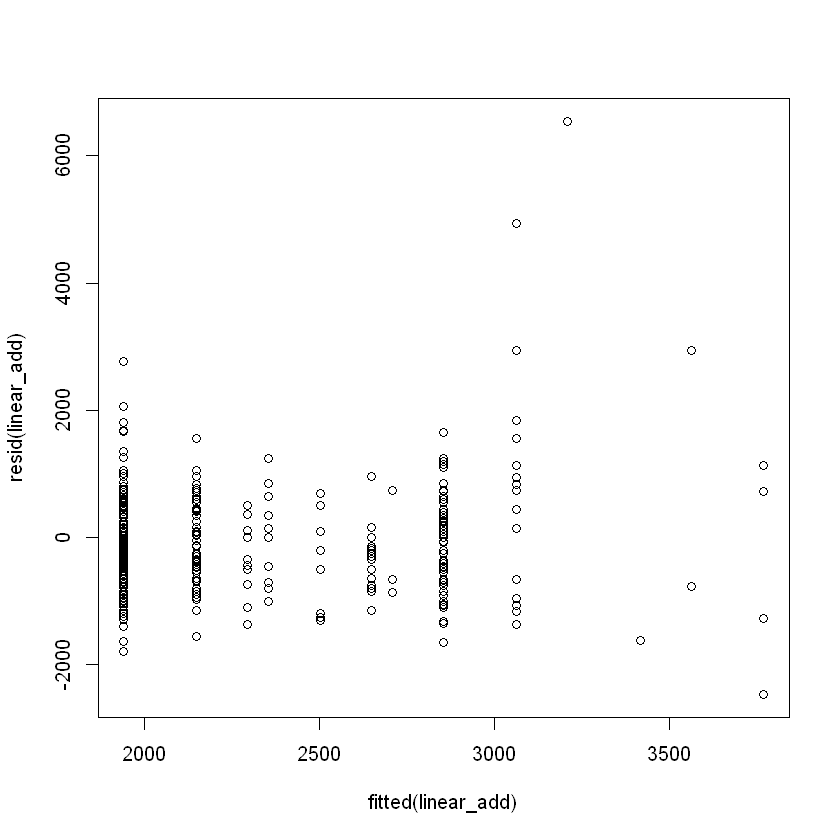

In [10]:
plot(linear_add, 2)
plot(fitted(linear_add), resid(linear_add))

In [11]:
linear_mult <- lm(price ~ bedroom * bathroom, data = data)

linear_mult_results <- 
   tidy(linear_mult, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
linear_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),1609.69,238.10,6.76,0.00,1142.32,2077.07
bedroom,-131.33,141.90,-0.93,0.35,-409.86,147.20
bathroom,215.80,203.38,1.06,0.29,-183.42,615.02
bedroom:bathroom,263.75,102.30,2.58,0.01,62.94,464.56


**Not statistically significant. Also you can just tell its wrong, like why is the estimate for bedroom negative come on**

In [12]:
logistic_add <- glm(high_price ~ bedroom + bathroom, data = data)

logistic_add_results <- 
   tidy(logistic_add, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
logistic_add_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.04,0.05,-0.85,0.40,-0.14,0.06
bedroom,0.05,0.04,1.30,0.19,-0.02,0.12
bathroom,0.36,0.05,7.44,0.00,0.27,0.46


In [13]:
logistic_mult <- glm(high_price ~ bedroom * bathroom, data = data)

logistic_mult_results <- 
   tidy(logistic_mult, conf.int = TRUE, conf.level = 0.95) %>%
   mutate_if(is.numeric, round, 2)
logistic_mult_results

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.29,0.16,-1.77,0.08,-0.61,0.03
bedroom,0.19,0.10,1.96,0.05,0.00,0.38
bathroom,0.57,0.14,4.07,0.00,0.29,0.84
bedroom:bathroom,-0.11,0.07,-1.58,0.11,-0.25,0.03


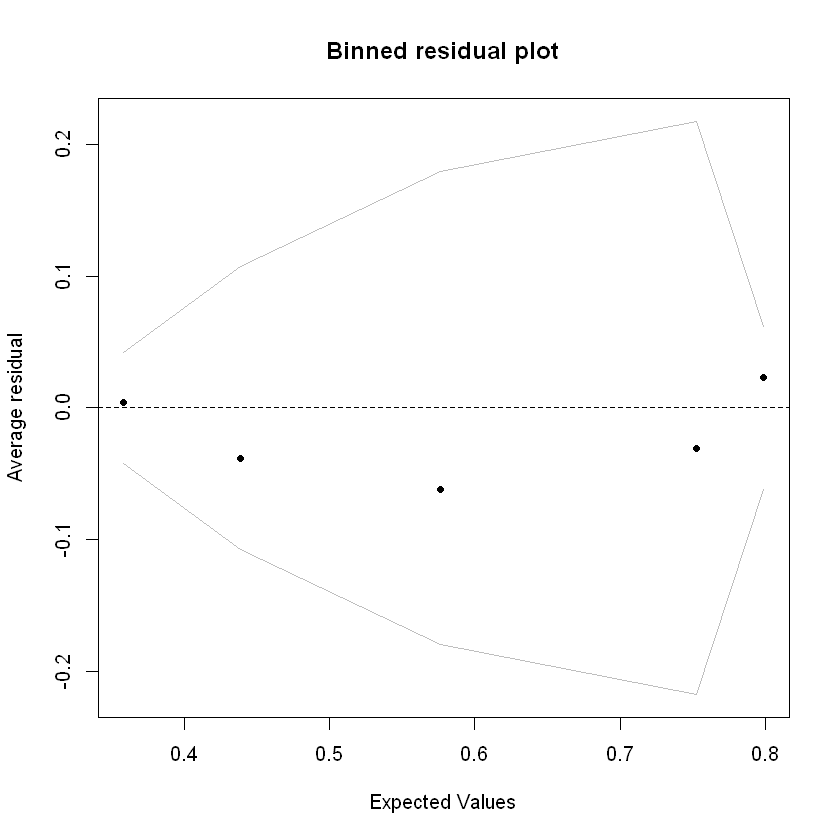

In [14]:
binnedplot(fitted(logistic_mult), resid(logistic_mult))

In [15]:
data <-
    data %>% 
    add_predictions(linear, var = 'linear_predictions')

linear_plot <- 
    data %>%
    ggplot(aes(x = bedroom, y = price, color = bathroom)) +
    geom_point() +
    geom_line(aes(y = linear_predictions), linewidth = 1) +
    labs(title = 'Reading score vs income by grade range without interactions',
         x = 'Number of bedrooms',
         y = 'Price') +
    theme(text = element_text(size = 16.5),
          plot.title = element_text(face = "bold"),
          axis.title = element_text(face = "bold"),
          legend.title = element_text(face = "bold")) +
    labs(color = "Number of bathrooms")

# your code here
# fail() # No Answer - remove if you provide an answer

# linear_plot

ERROR: Error: object 'linear' not found
